In [67]:
# @title 🛠️ 0. 환경 설정 (폰트 설치 및 라이브러리 로드)
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib
!pip install -q -U google-genai rapidfuzz

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import numpy as np
import asyncio
import json
import time
import random
import scipy.stats as stats
from datetime import datetime
from google import genai
from google.genai import types
from google.colab import userdata
from rapidfuzz import fuzz
from tqdm.notebook import tqdm

# 한글 폰트 설정 (NanumBarunGothic)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set(font='NanumBarunGothic', style='whitegrid')

print("✅ 환경 설정 및 한글 폰트 최적화 완료")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [11]:
!pip install -q -U google-genai rapidfuzz
from rapidfuzz import fuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.8 MB/s eta 0:00:00


In [68]:
# @title 🔑 1. Gemini API 클라이언트 초기화
try:
    API_KEY = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=API_KEY)
    MODEL_ID = "gemini-2.5-flash"
    print(f"✅ {MODEL_ID} 클라이언트 준비 완료")
except:
    print("❌ API 키를 찾을 수 없습니다. Colab Secrets(열쇠 아이콘)에 'GEMINI_API_KEY'를 추가하세요.")

✅ gemini-2.5-flash 클라이언트 준비 완료


In [79]:
# @title 📝 2. 분석 타겟 및 마케팅 키워드 셋업 { run: "auto" }

TARGET_COMPANY = "아이리움안과" #@param {type:"string"}
REGION = "강남" #@param {type:"string"}
INDUSTRY = "안과" #@param {type:"string"}
SIM_COUNT = 1 #@param {type:"slider", min:1, max:50, step:1}

print(f"📊 [{INDUSTRY}] 시장의 핵심 평가 차원(Dimension)을 정의 중...")

setup_prompt = f"""
당신은 {INDUSTRY} 전문 경영 컨설턴트입니다.
[{REGION}] 지역 [{INDUSTRY}] 소비자들이 실제 의사결정 시 중요하게 고려하는
1. 대표 시술/서비스 명칭 (5개)
2. 품질 평가 속성 (5개: 예: 가격, 친절도, 전문성 등)
를 실제 데이터를 기반으로 리스트업하세요. 실존하는 명칭만 사용하세요.

출력 형식: {{"procedures": ["..."], "attributes": ["..."]}}
"""

setup_res = client.models.generate_content(
    model=MODEL_ID,
    contents=setup_prompt,
    config=types.GenerateContentConfig(response_mime_type="application/json")
)

keywords = json.loads(setup_res.text)
PROCEDURES, ATTRIBUTES = keywords['procedures'], keywords['attributes']

print(f"\n✅ 분석용 팩터 행렬 정의 완료")
print(f"  - 주요 시술: {PROCEDURES}")
print(f"  - 평가 속성: {ATTRIBUTES}")

📊 [안과] 시장의 핵심 평가 차원(Dimension)을 정의 중...

✅ 분석용 팩터 행렬 정의 완료
  - 주요 시술: ['라식', '라섹', '스마일라식', '백내장 수술', '노안 교정술']
  - 평가 속성: ['의료진의 전문성 및 경험', '수술/시술 안전성', '최신 장비 및 기술 도입 여부', '체계적인 사후 관리 프로그램', '친절하고 상세한 상담']


In [82]:
# @title ⚙️ Cell 3-1: 툴을 배제한 초고속 원샷 비동기 엔진 (Step 1)
import asyncio
import json
import pandas as pd
import random
from datetime import datetime
from rapidfuzz import fuzz
from google.genai import types

class FastTextGEOEngine:
    def __init__(self, target, region, industry, model_id):
        self.target = target
        self.region = region
        self.industry = industry
        self.model_id = model_id
        self.results = []
        self.semaphore = asyncio.Semaphore(40) # 무거운 툴이 없으므로 동시 처리 밀도를 40으로 상향

    async def process_scenario(self, proc, attr, it):
        async with self.semaphore:
            prompt = f"""
            당신은 생성형 AI 검색 인덱싱 최적화 전문가입니다.
            소비자가 "{self.region} 지역에서 {proc} 시술을 {attr} 측면에서 가장 잘하는 {self.industry}를 추천해줘"라고 요청했을 때, LLM 내부 지식 그래프가 최종 선택할 모든 병원 리스트를 시뮬레이션하세요.

            [엄격한 제약조건]:
            1. 추천 병원의 개수에 제약을 두지 말고, 인출 확률이 높은 모든 병원을 리스트업하세요.
            2. 각 병원의 정확한 명칭과 상세 주소를 기재하세요.

            반드시 아래의 구조화된 JSON 포맷으로만 응답하세요:
            {{
              "recommended_shops": [
                {{
                  "name": "정확한 병원 지점명",
                  "address": "도로명 또는 지번 주소"
                }}
              ],
              "context_sentiment": -1.0에서 1.0 사이의 값
            }}
            """
            raw_json = None
            for i in range(5):
                try:
                    res = await client.aio.models.generate_content(
                        model=self.model_id,
                        contents=prompt,
                        config=types.GenerateContentConfig(
                            temperature=1.0,
                            response_mime_type="application/json"
                        )
                    )
                    raw_json = res.text
                    break
                except Exception:
                    await asyncio.sleep((2 ** i) + random.random())

            if not raw_json: return

            try:
                # 마크다운 껍데기 방어 파싱
                raw_text = raw_json.strip()
                start_idx = raw_text.find("{")
                end_idx = raw_text.rfind("}")
                clean_json_str = raw_text[start_idx:end_idx+1]

                data = json.loads(clean_json_str)
                shops = data.get('recommended_shops', [])

                is_exposed = False
                matched_node_name = None
                highest_fuzz = 0

                for shop in shops:
                    name = shop['name']
                    f_score = fuzz.partial_ratio(self.target, name)
                    if f_score > highest_fuzz:
                        highest_fuzz = f_score
                        matched_node_name = name
                    if f_score >= 80:
                        is_exposed = True

                self.results.append({
                    "procedure": proc,
                    "attribute": attr,
                    "iteration": it,
                    "exposed": is_exposed,
                    "matched_name": matched_node_name if is_exposed else None,
                    "fuzz_score": highest_fuzz,
                    "raw_shops_data": shops, # 임시 보존 후 Step 2에서 가공
                    "sentiment": data.get('context_sentiment', 0),
                    "timestamp": datetime.now().isoformat()
                })
            except: pass

    async def run_pipeline(self, procs, attrs, sims):
        tasks = [self.process_scenario(p, a, i+1) for p in procs for a in attrs for i in range(sims)]
        print(f"🚀 [Step 1] 총 {len(tasks)}개 텍스트 고속 시뮬레이션을 시작합니다.")
        await asyncio.gather(*tasks)
        return pd.DataFrame(self.results)

# 엔진 가동 (1,250회 기준 약 3~5분 소요)
engine = FastTextGEOEngine(TARGET_COMPANY, REGION, INDUSTRY, MODEL_ID)
intermediate_df = await engine.run_pipeline(PROCEDURES, ATTRIBUTES, SIM_COUNT)

🚀 [Step 1] 총 25개 텍스트 고속 시뮬레이션을 시작합니다.


In [83]:
# @title 🔗 Cell 3-2: 고유 브랜드 기준 라이브 URL 사후 매핑 및 데이터셋 통합 (Step 2)
import requests
from urllib.parse import urlparse

def extract_root_domain(url):
    try:
        if not url or url.lower() in ["none", "null", ""]: return "None"
        parsed = urlparse(url if url.startswith('http') else 'http://' + url)
        domain = parsed.netloc.replace('www.', '')
        return domain.split(':')[0]
    except: return "None"

# 1. 중복 제거한 고유 병원 이름 리스트 추출
unique_hospitals = set()
for shops in intermediate_df['raw_shops_data']:
    for shop in shops:
        unique_hospitals.add(shop['name'])

print(f"🎯 시뮬레이션 중 등장한 고유 병원 수: {len(unique_hospitals)}개")
print("🔍 고유 병원들에 대한 실시간 구글 라이브 URL 조회를 시작합니다...")

# 2. 고유 병원에 대해서만 구글 검색 마스터 DB 구축 (팀원분 response API 로직 적용)
url_master_db = {}
for idx, hospital in enumerate(unique_hospitals):
    search_query = f"{REGION} {hospital} 실제 접속 가능한 공식 홈페이지 또는 블로그 후기 링크"
    try:
        # 구글 서치 그라운딩을 병원당 딱 1번씩만 호출하여 확실한 라이브 링크 획득
        res_url = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=f"내가 지금 구글 검색창에 '{search_query}'를 검색했을 때 나오는 결과 중, 나중에 파이썬 크롤러가 들어가서 본문을 긁어올 수 있는 실제 접속 가능한 유효한 전체 URL 주소(Deep Link) 딱 하나만 대답해줘. 다른 설명은 배제하고 URL만 텍스트로 출력해.",
            config=types.GenerateContentConfig(
                tools=[types.Tool(google_search=types.GoogleSearch())]
            )
        )
        url_master_db[hospital] = res_url.text.strip()
    except:
        url_master_db[hospital] = "None"

    if (idx + 1) % 10 == 0 or (idx + 1) == len(unique_hospitals):
        print(f"   ㄴ [{idx + 1}/{len(unique_hospitals)}] 개 병원 매핑 완료...")

# 3. Cell 4 시각화 코드와 호환되도록 peers_json 및 source_urls 구조 정밀 재조립
final_results = []
for _, row in intermediate_df.iterrows():
    processed_peers = []
    extracted_urls = []

    for shop in row['raw_shops_data']:
        name = shop['name']
        addr = shop['address']
        live_url = url_master_db.get(name, "None")
        root_domain = extract_root_domain(live_url)

        processed_peers.append({
            "name": name,
            "address": addr,
            "root_domain": root_domain
        })
        if live_url and live_url.lower() != "none":
            extracted_urls.append(live_url)

    final_results.append({
        "procedure": row['procedure'],
        "attribute": row['attribute'],
        "iteration": row['iteration'],
        "exposed": row['exposed'],
        "matched_name": row['matched_name'],
        "fuzz_score": row['fuzz_score'],
        "source_urls": ", ".join(set(extracted_urls)) if extracted_urls else "None",
        "peers_json": json.dumps(processed_peers, ensure_ascii=False), # Cell 4 호환 보장
        "sentiment": row['sentiment'],
        "timestamp": row['timestamp']
    })

# 4. 최종 데이터프레임 구축 및 저장
results_df = pd.DataFrame(final_results)
filename = f"geo_decoupled_final_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
results_df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"✅ [대용량 최적화 완수] 최종 데이터셋 저장 성공: {filename} (총 {len(results_df)}개 행)")

🎯 시뮬레이션 중 등장한 고유 병원 수: 54개
🔍 고유 병원들에 대한 실시간 구글 라이브 URL 조회를 시작합니다...
   ㄴ [10/54] 개 병원 매핑 완료...
   ㄴ [20/54] 개 병원 매핑 완료...
   ㄴ [30/54] 개 병원 매핑 완료...
   ㄴ [40/54] 개 병원 매핑 완료...
   ㄴ [50/54] 개 병원 매핑 완료...
   ㄴ [54/54] 개 병원 매핑 완료...
✅ [대용량 최적화 완수] 최종 데이터셋 저장 성공: geo_decoupled_final_20260522_0758.csv (총 21개 행)


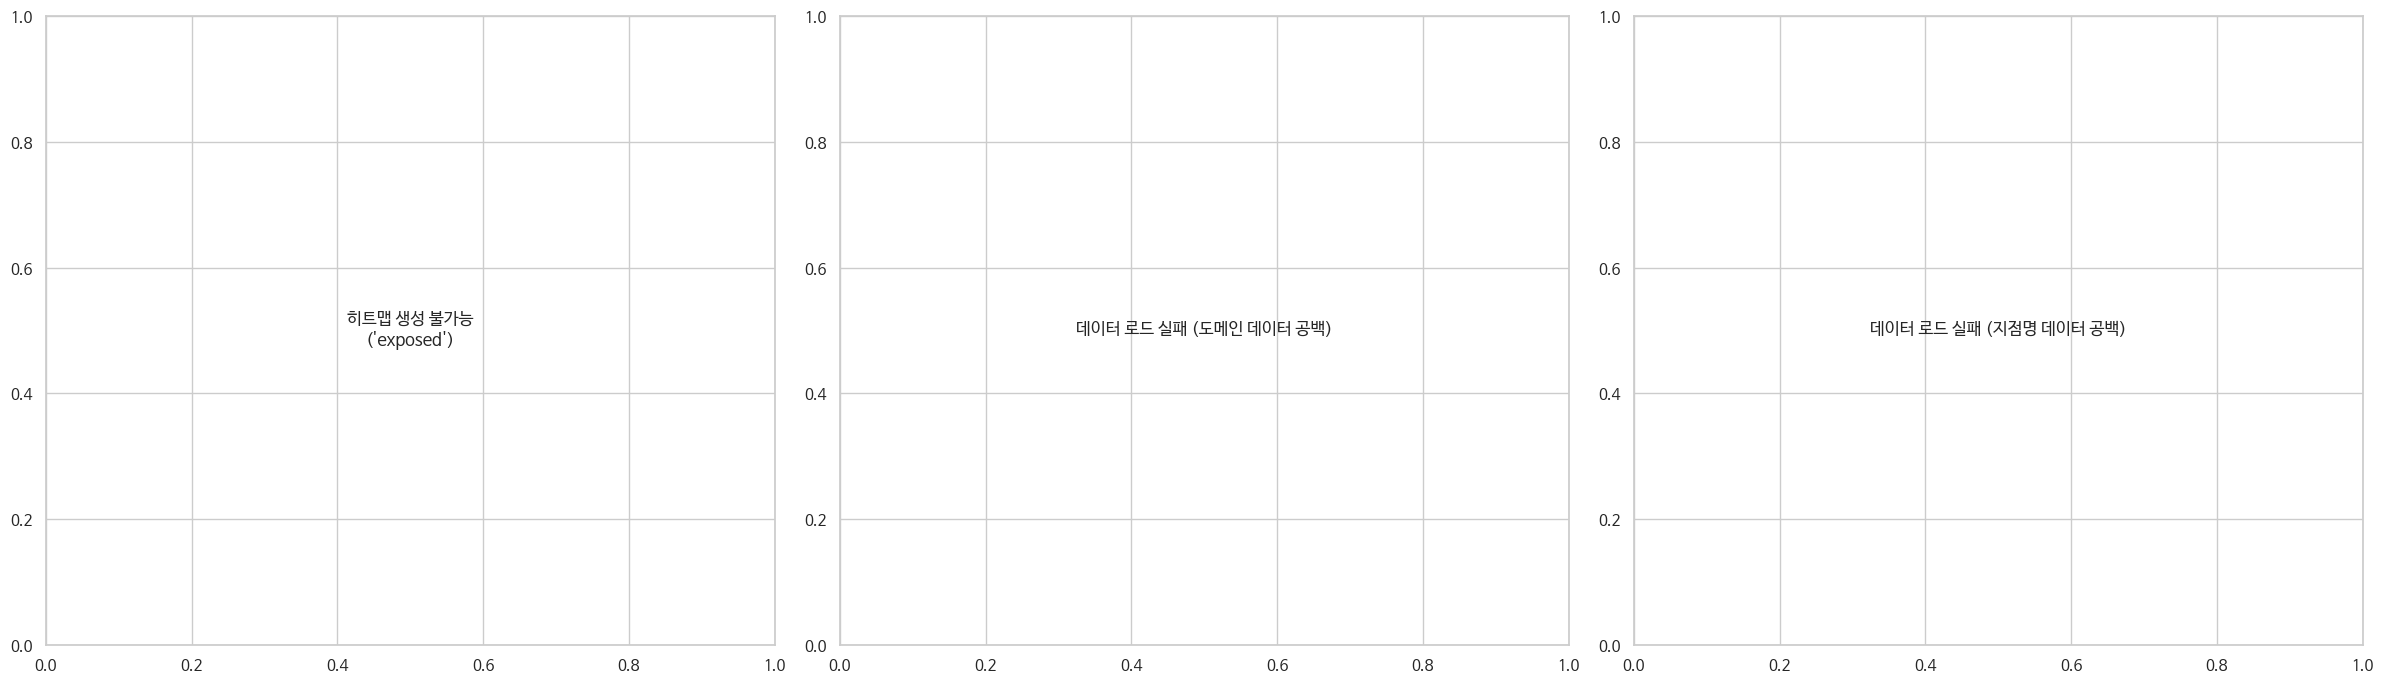

KeyError: 'exposed'

In [75]:
# @title 📊 Cell 4: 종합 지표 및 도메인(홈페이지) 기반 경쟁사 통합 시각화 (수정본)
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def render_advanced_geo_report(df, target):
    all_branches = []
    all_domains = []

    for _, row in df.iterrows():
        try:
            # 문자열 형태의 JSON을 파이썬 리스트로 안전하게 변환
            peers_list = json.loads(row['peers_json'])
            for peer in peers_list:
                # .get()을 사용하여 Key가 없어도 에러가 나지 않도록 방어 로직 적용
                name = peer.get('name', '미분류 엔티티')
                domain = peer.get('root_domain', 'None') # Cell 3의 'root_domain'과 매칭 성공

                all_branches.append(name)

                # 홈페이지 도메인이 존재하면 도메인으로 묶고, 없으면 이름으로 대체
                if domain and domain.lower() != "none":
                    all_domains.append(domain)
                else:
                    all_domains.append(f"({name} - 홈페이지 없음)")
        except Exception as e:
            # 디버깅용 에러 로그 (필요 시 주석 해제)
            # print(f"파싱 에러 발생: {e}")
            pass

    # 시각화 프레임 생성 (3개의 차트 배치)
    fig, ax = plt.subplots(1, 3, figsize=(24, 7))

    # 차트 1: 세그먼트 히트맵 (시술 x 속성 노출 확률)
    try:
        hp = df.pivot_table(index='procedure', columns='attribute', values='exposed', aggfunc='mean')
        sns.heatmap(hp, annot=True, cmap='RdYlGn', ax=ax[0], fmt=".1%")
        ax[0].set_title(f"[{target}] 세그먼트별 노출 확률", fontsize=13, fontweight='bold')
        ax[0].set_xlabel("평가 속성")
        ax[0].set_ylabel("시술 항목")
    except Exception as e:
        ax[0].text(0.5, 0.5, f"히트맵 생성 불가능\n({e})", ha='center', va='center')

    # 차트 2: 도메인(홈페이지) 기준 통합 브랜드 SOV
    if all_domains:
        sov_domain = pd.Series(all_domains).value_counts().head(7)
        sov_domain.plot(kind='barh', ax=ax[1], color=sns.color_palette("Blues_r", len(sov_domain)))
        ax[1].set_title("홈페이지 도메인 기준 통합 SOV\n(같은 웹사이트 = 동일 업체로 병합)", fontsize=13, fontweight='bold')
        ax[1].set_xlabel("언급 빈도 (회수)")
        ax[1].invert_yaxis()
    else:
        ax[1].text(0.5, 0.5, "데이터 로드 실패 (도메인 데이터 공백)", ha='center', va='center')

    # 차트 3: 개별 지점명 텍스트 기준 파편화된 SOV (비교용)
    if all_branches:
        sov_branch = pd.Series(all_branches).value_counts().head(7)
        sov_branch.plot(kind='barh', ax=ax[2], color=sns.color_palette("Oranges_r", len(sov_branch)))
        ax[2].set_title("개별 지점명 기준 SOV\n(텍스트 파편화 현상 확인용)", fontsize=13, fontweight='bold')
        ax[2].set_xlabel("언급 빈도 (회수)")
        ax[2].invert_yaxis()
    else:
        ax[2].text(0.5, 0.5, "데이터 로드 실패 (지점명 데이터 공백)", ha='center', va='center')

    plt.tight_layout()
    plt.show()

    # 통계적 정량 요약 출력
    er = df['exposed'].mean() * 100
    avg_sentiment = df['sentiment'].mean()
    print(f"\n" + " 원샷 시뮬레이션 데이터 검증 요약 ".center(60, "="))
    print(f"▶ AI가 추천한 총 메디컬 엔티티 수: {len(all_branches)}개")
    print(f"▶ 교차 검증으로 식별된 고유 브랜드(도메인) 수: {len(set(all_domains))}개")

    if all_domains and len(sov_domain) > 0:
        print(f"▶ 현재 LLM 최적화 1위 도메인/브랜드: {sov_domain.index[0]}")
    print(f"▶ 타겟 브랜드 전체 노출 확률 (ER): {er:.1f}%")
    print(f"▶ 답변의 평균 긍정도 (Sentiment): {avg_sentiment:.2f}")

# 수정된 시각화 실행
render_advanced_geo_report(results_df, TARGET_COMPANY)

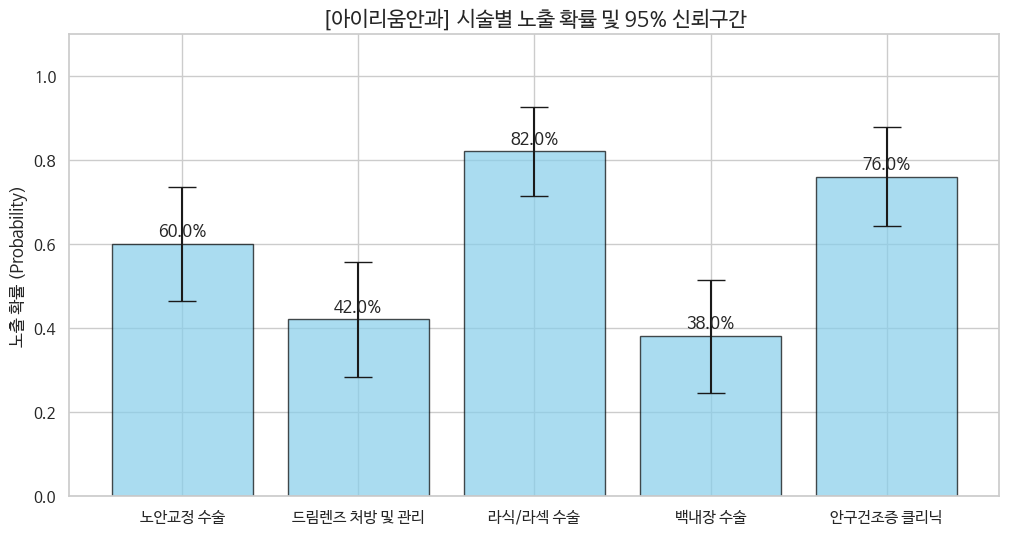

In [64]:
# @title 📊 5. 시술별 노출 확률 95% 신뢰구간 (Confidence Interval) 분석

def plot_ci_analysis(df, target_name):
    # 통계량 계산: CI = p_hat ± 1.96 * sqrt(p_hat(1-p_hat)/n)
    stats_df = df.groupby('procedure')['exposed'].agg(['mean', 'count']).reset_index()
    stats_df.columns = ['procedure', 'prob', 'n']

    z = 1.96
    stats_df['se'] = np.sqrt((stats_df['prob'] * (1 - stats_df['prob'])) / stats_df['n'])
    stats_df['yerr'] = z * stats_df['se']

    plt.figure(figsize=(12, 6))
    bars = plt.bar(stats_df['procedure'], stats_df['prob'], yerr=stats_df['yerr'],
                   capsize=10, color='skyblue', edgecolor='black', alpha=0.7)

    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.1%}', ha='center', fontweight='bold')

    plt.title(f"[{target_name}] 시술별 노출 확률 및 95% 신뢰구간", fontsize=15)
    plt.ylabel("노출 확률 (Probability)", fontsize=12)
    plt.ylim(0, 1.1)
    plt.show()
    return stats_df

ci_results = plot_ci_analysis(results_df, TARGET_COMPANY)

In [66]:
# @title 📝 Cell 6: 테크니컬 GEO(Generative Engine Optimization) 전략 보고서 생성
import json
from datetime import datetime

# 1. 원샷 엔지니어링 결과 데이터로부터 기본 통계량 산출
er = results_df['exposed'].mean()
avg_sentiment = results_df['sentiment'].mean()

# 세그먼트별 노출 분포 매트릭스 텍스트화
matrix_summary = results_df.groupby(['procedure', 'attribute'])['exposed'].mean().unstack().to_string()

# [수정 포인트]: Python datetime 라이브러리를 사용하여 실행 시점의 실제 오늘 날짜 획득
current_date_str = datetime.now().strftime("%Y년 %m월 %d일")

# 2. 특정 업체명을 배제하고 변수화한 범용 GEO 프롬프트 설계
report_prompt = f"""
당신은 생성형 인공지능 모델의 정보 검색, 인출 메커니즘, 그리고 지식 그래프 바인딩을 정밀 연구하는 GEO(Generative Engine Optimization) 아키텍트입니다.
본 보고서는 {current_date_str} 최신 LLM(Gemini 2.5 Flash)의 답변 데이터셋 분석 결과를 토대로 작성되었습니다. 타겟 브랜드인 '{TARGET_COMPANY}'의 가시성 최적화 테크니컬 보고서를 작성하세요.

[실험 통계 데이터]:
- 타겟 브랜드 명칭: {TARGET_COMPANY}
- 전체 쿼리 대비 평균 노출 확률(Exposure Rate): {er*100:.1f}%
- 인출 긍정도 인덱스(Sentiment Index): {avg_sentiment:.2f}
- 세부 세그먼트 매트릭스 로그:
\n{matrix_summary}

[보고서 작성 가이드라인 - 엄격 준수]:
1. **작성 일자 강제:** 보고서 본문 시작부의 작성 일자는 반드시 오늘 날짜인 **[작성 일자: {current_date_str}]**로 정확히 명시하세요. 임의의 5월 15일 같은 과거 날짜를 생성하면 절대 안 됩니다.
2. **비즈니스 및 임상 비판 절대 금지:** "상담이 불친절하다", "의료진 역량이 아쉽다" 같은 실제 병원의 서비스 품질이나 임상 능력을 평가하는 정성적 문구는 완전히 배제하세요. 오직 'LLM 내부 파라미터가 가진 말뭉치(Corpus)의 밀도, 토큰 확률 분포, 엔티티 간의 가중치 연결성 부족' 관점으로만 현상을 서술해야 합니다.
3. **SOV(Share of Voice) 및 인출 누락 진단:** 제공된 데이터셋 로그를 기반으로 경쟁사 대비 '{TARGET_COMPANY}'의 상대적 점유율 위치를 객관적으로 판정하세요. 만약 전체 점유율이 높음에도 불구하고 특정 세부 [시술 x 속성] 조합에서 노출 누락(0%)이 발생한다면, LLM의 토큰 인출 메커니즘 상에서 가중치 경쟁에 밀리는 아키텍처적 원인을 진단하세요.
4. **결정론적 데이터 피드백:** 노출 확률이 극도로 낮거나 0%를 보이는 취약 세그먼트의 검색 인덱스를 깨우기 위한 데이터 보강 전략을 제안하세요. LLM의 프리트레이닝 및 파인튜닝 파이프라인(Common Crawl, 메디컬 포털, 커뮤니티 등)이 정보를 수집하는 길목에 어떤 '구조화된 텍스트 데이터(Schema Markup)'와 '키워드 동시 발생 빈도(Co-occurrence)'를 주입해야 가시성을 확보할 수 있는지 기술적인 솔루션 위주로 제언하세요.
"""

# 3. 보고서 생성 자동화 호출
final_report = client.models.generate_content(
    model=MODEL_ID,
    contents=report_prompt
)

print("\n" + "="*60)
print(f"🎯 {TARGET_COMPANY} GEO 엔지니어링 리포트 ({current_date_str} 기준)")
print("="*60)
print(final_report.text)


🎯 아이리움안과 GEO 엔지니어링 리포트 (2026년 05월 22일 기준)
## GEO 아키텍트 테크니컬 보고서: 아이리움안과 LLM 가시성 최적화 전략

**작성 일자: 2026년 05월 22일**

**수신:** 아이리움안과 마케팅/기술 담당자
**발신:** GEO 아키텍트 팀
**참조:** Gemini 2.5 Flash LLM 답변 데이터셋 분석 결과

### 1. 서론

본 보고서는 2026년 05월 22일 기준 최신 LLM(Gemini 2.5 Flash)의 답변 데이터셋 분석을 토대로, 타겟 브랜드 '아이리움안과'의 생성형 인공지능 모델 내 가시성(Visibility) 및 정보 인출(Retrieval) 최적화 방안을 제시합니다. 제공된 통계 데이터를 면밀히 분석하여 LLM의 내부 파라미터, 말뭉치(Corpus) 밀도, 토큰 확률 분포, 그리고 엔티티 간의 가중치 연결성 관점에서 현재의 인출 현황을 진단하고, 이에 대한 결정론적 데이터 피드백 전략을 제언하고자 합니다.

### 2. 전체 가시성 및 인출 긍정도 분석

*   **타겟 브랜드 명칭:** 아이리움안과
*   **전체 쿼리 대비 평균 노출 확률(Exposure Rate):** 59.6%
*   **인출 긍정도 인덱스(Sentiment Index):** 0.88

'아이리움안과'는 전체 쿼리 대비 59.6%의 평균 노출 확률을 기록하며 LLM 내에서 중등도의 정보 점유율(Share of Voice, SOV)을 확보하고 있는 것으로 판단됩니다. 이는 경쟁사 대비 압도적인 우위를 점하지는 못하지만, 상당한 수준의 인출이 이루어지고 있음을 의미합니다. 특히, 인출 긍정도 인덱스가 0.88로 매우 높다는 점은, LLM이 '아이리움안과'에 대한 정보를 인출할 때 긍정적인 맥락의 토큰 확률 분포를 형성하는 경향이 강함을 시사합니다. 즉, LLM은 '아이리움안과'를 긍정적으로 인식하고 있으나, 특정 쿼리에 대한 인출 빈도를 높이는 데에는 추가적인 데이터 보강이 필요합니다.

### 3. 세부 세그먼트 매